# Week 3 Assignment - Customer Intelligence System
### Harshit Nagar

Using the Country dataset to build a customer intelligence system with clustering, classification and ensemble methods.

In [2]:
!pip install -q xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, StackingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set(style='whitegrid')
print('all imports done')

all imports done


In [4]:
import os

# loading the dataset
if os.path.exists('DataSets/Country-data.csv'):
    df = pd.read_csv('DataSets/Country-data.csv')
elif os.path.exists('Country-data.csv'):
    df = pd.read_csv('Country-data.csv')
else:
    # for google colab
    from google.colab import files
    import io
    uploaded = files.upload()
    df = pd.read_csv(io.BytesIO(uploaded[next(iter(uploaded))]))

print('shape:', df.shape)
df.head()

shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [7]:
print('missing values:')
print(df.isnull().sum())

missing values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [8]:
# clean column names
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

# make sure all non-country columns are numeric
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = [c for c in df.columns if c != 'country']

# fill any missing values with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print('after cleaning:', df.shape)
df.head()

after cleaning: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Exploratory Data Analysis

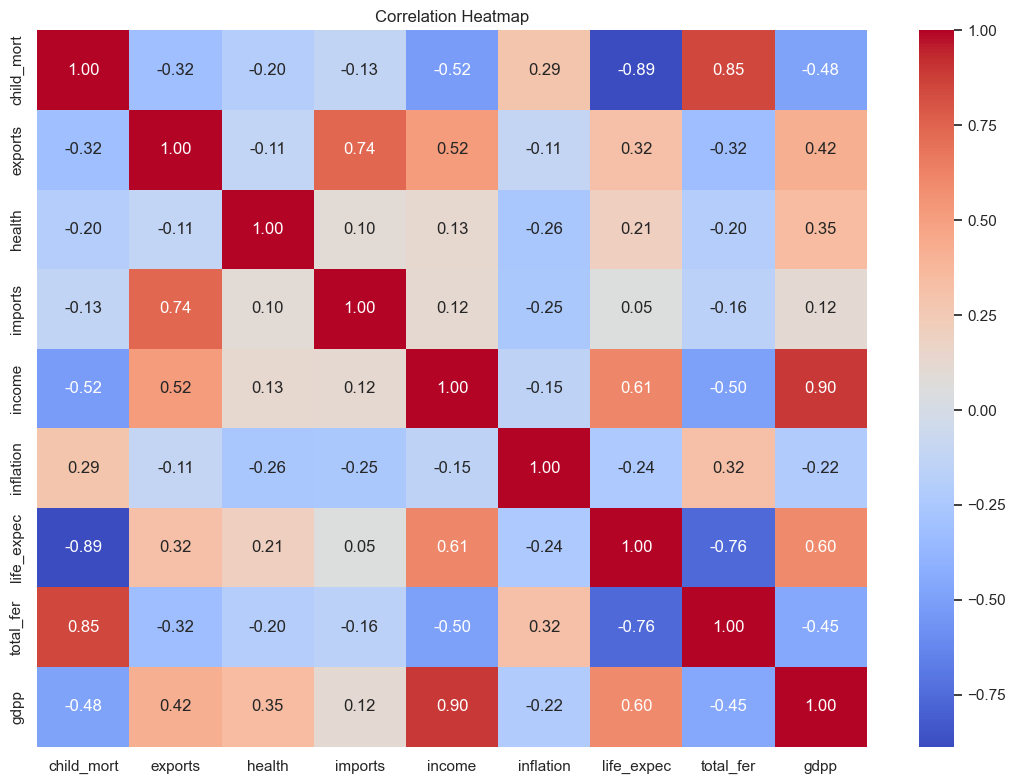

In [9]:
plt.figure(figsize=(11, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

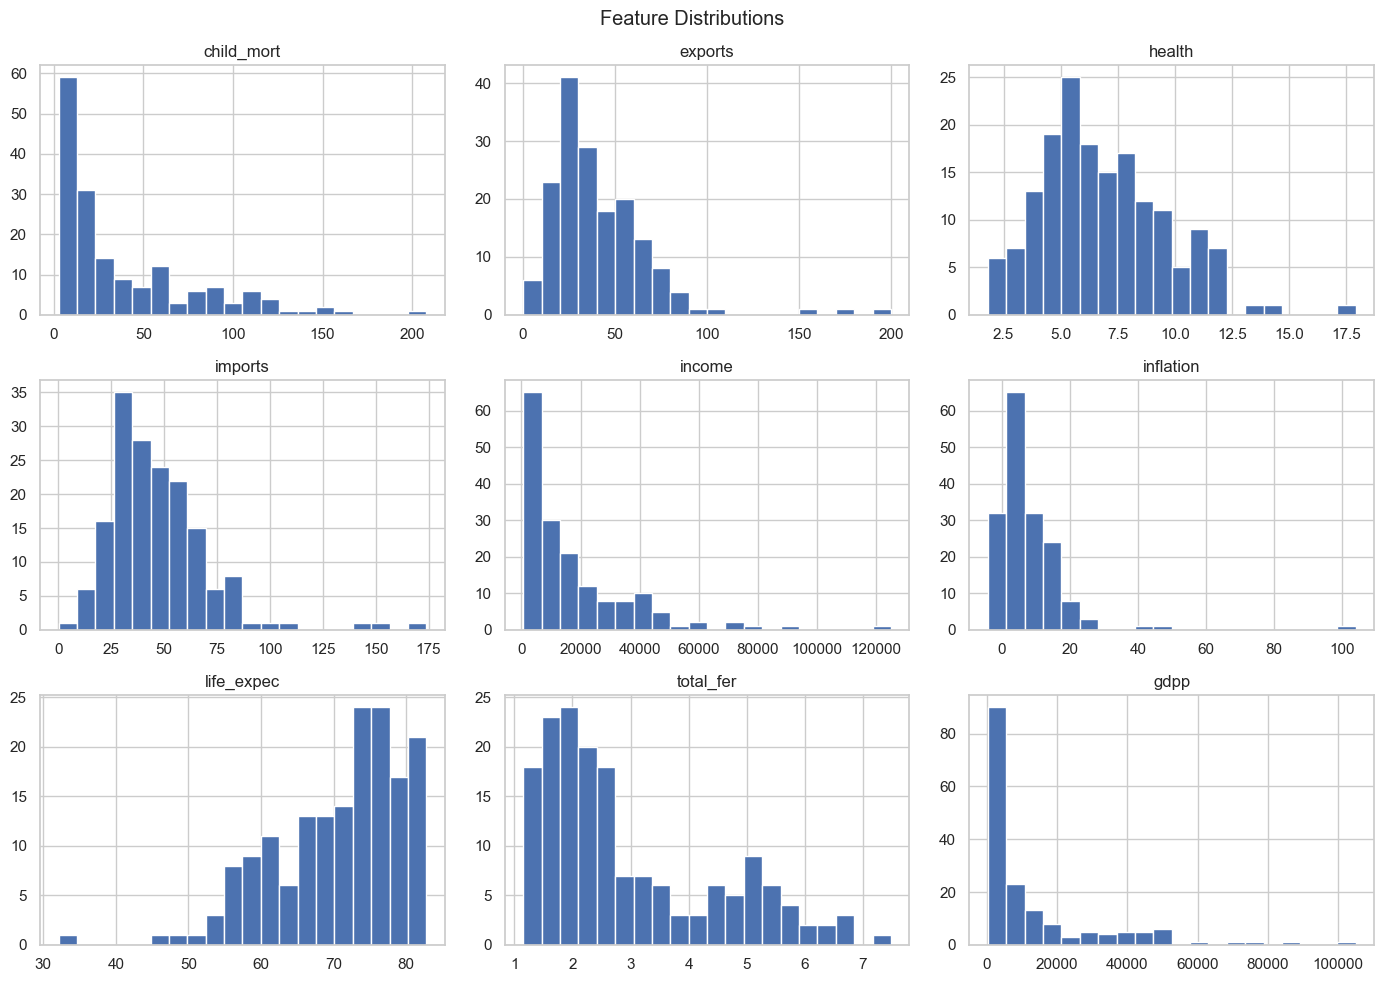

In [10]:
# distribution of each feature
df[numeric_cols].hist(bins=20, figsize=(14, 10))
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

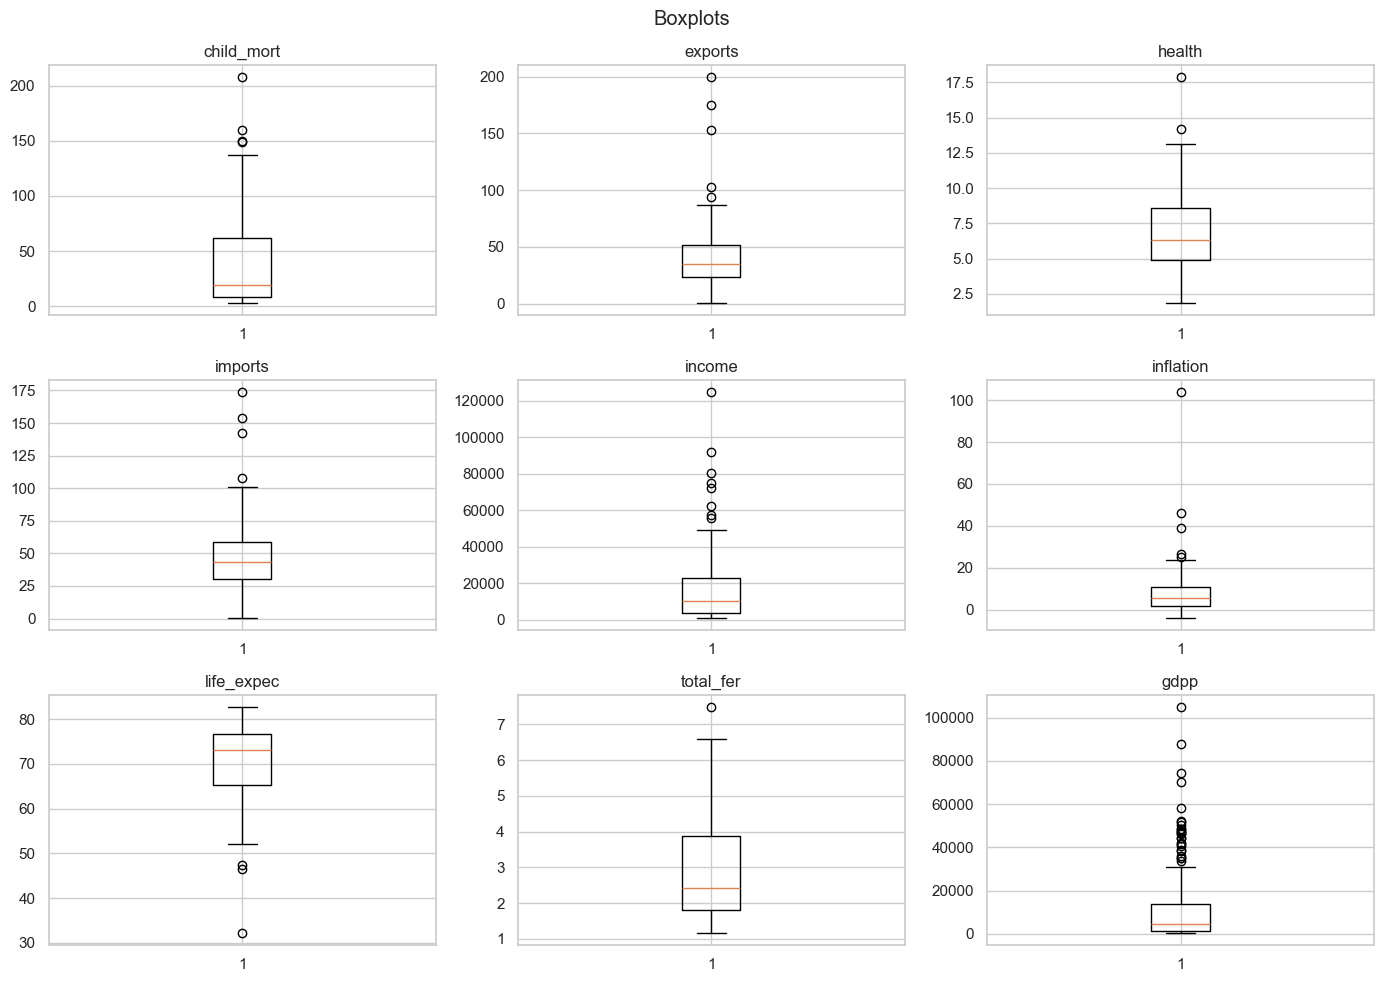

In [12]:
# boxplots to see outliers
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, col in enumerate(numeric_cols):
    ax = axes[i // 3][i % 3]
    ax.boxplot(df[col])
    ax.set_title(col)
plt.suptitle('Boxplots')
plt.tight_layout()
plt.show()

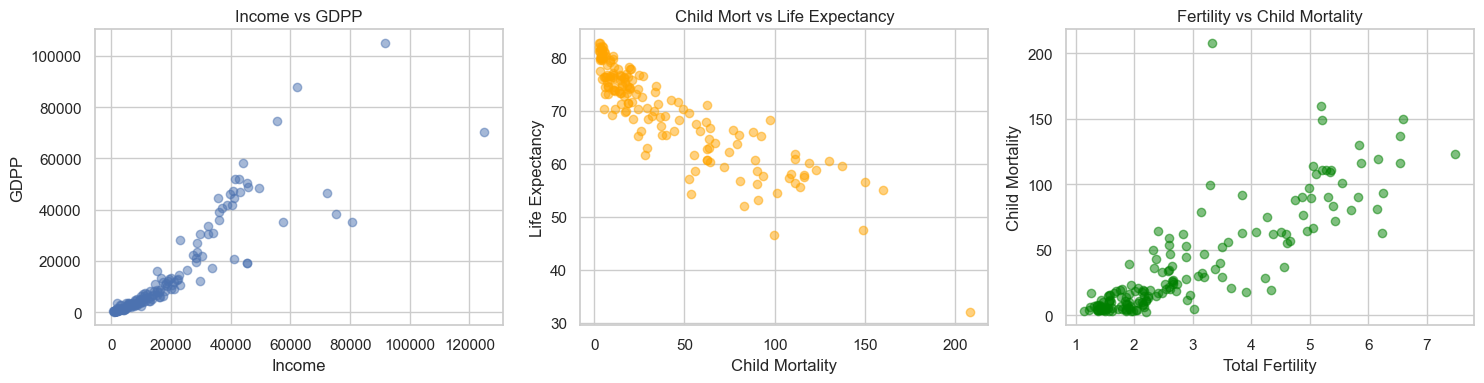

In [13]:
# looking at relationship between income, gdpp, child_mort and life_expec
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df['income'], df['gdpp'], alpha=0.5)
axes[0].set_xlabel('Income')
axes[0].set_ylabel('GDPP')
axes[0].set_title('Income vs GDPP')

axes[1].scatter(df['child_mort'], df['life_expec'], alpha=0.5, color='orange')
axes[1].set_xlabel('Child Mortality')
axes[1].set_ylabel('Life Expectancy')
axes[1].set_title('Child Mort vs Life Expectancy')

axes[2].scatter(df['total_fer'], df['child_mort'], alpha=0.5, color='green')
axes[2].set_xlabel('Total Fertility')
axes[2].set_ylabel('Child Mortality')
axes[2].set_title('Fertility vs Child Mortality')

plt.tight_layout()
plt.show()

## Feature Scaling

Scaling is important before clustering and distance based algorithms so that features with large ranges don't dominate.

In [14]:
features = df[numeric_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print('shape after scaling:', X_scaled.shape)
print('mean (should be ~0):', X_scaled.mean(axis=0).round(3))
print('std  (should be ~1):', X_scaled.std(axis=0).round(3))

shape after scaling: (167, 9)
mean (should be ~0): [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Clustering

### K-Means

First using the elbow method to find the right number of clusters.

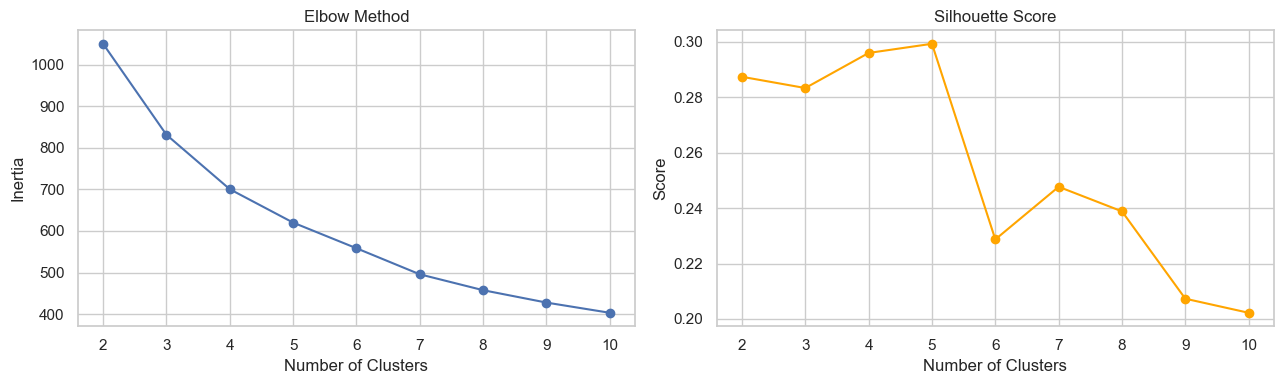

best k by silhouette: 5


In [15]:
inertia = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), inertia, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), sil_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

best = list(k_range)[sil_scores.index(max(sil_scores))]
print(f'best k by silhouette: {best}')

In [16]:
# k=3 looks good from both elbow and silhouette
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['kmeans_label'] = kmeans.fit_predict(X_scaled)

print('Cluster distribution:')
print(df['kmeans_label'].value_counts().sort_index())
print()
print('Silhouette Score   :', round(silhouette_score(X_scaled, df['kmeans_label']), 4))
print('Davies-Bouldin     :', round(davies_bouldin_score(X_scaled, df['kmeans_label']), 4))
print('Calinski-Harabasz  :', round(calinski_harabasz_score(X_scaled, df['kmeans_label']), 2))

Cluster distribution:
kmeans_label
0    36
1    47
2    84
Name: count, dtype: int64

Silhouette Score   : 0.2833
Davies-Bouldin     : 1.2769
Calinski-Harabasz  : 66.23


### K-Medoids

Similar to K-Means but the cluster center is always an actual data point (medoid) instead of the mean. This makes it less sensitive to outliers.

In [17]:
def fit_kmedoids(X, k, random_state=42):
    np.random.seed(random_state)
    n = len(X)
    # pick k random points as initial medoids
    med = np.random.choice(n, k, replace=False)
    
    for _ in range(100):
        # assign each point to closest medoid
        dists = cdist(X, X[med])
        labels = dists.argmin(axis=1)
        
        new_med = med.copy()
        for c in range(k):
            pts = np.where(labels == c)[0]
            if len(pts) == 0:
                continue
            # medoid = point with minimum total distance to all others in cluster
            inner = cdist(X[pts], X[pts]).sum(axis=1)
            new_med[c] = pts[inner.argmin()]
        
        if np.all(new_med == med):
            break
        med = new_med
    
    labels = cdist(X, X[med]).argmin(axis=1)
    return labels, med


kmed_labels, kmed_centers = fit_kmedoids(X_scaled, k=3)
df['kmedoids_label'] = kmed_labels

print('K-Medoids cluster distribution:')
print(pd.Series(kmed_labels).value_counts().sort_index())
print()
print('Silhouette Score  :', round(silhouette_score(X_scaled, kmed_labels), 4))
print('Davies-Bouldin    :', round(davies_bouldin_score(X_scaled, kmed_labels), 4))
print('Calinski-Harabasz :', round(calinski_harabasz_score(X_scaled, kmed_labels), 2))
print()
print('Representative country per cluster (medoid):')
for i, idx in enumerate(kmed_centers):
    print(f'  Cluster {i}: {df.iloc[idx]["country"]}')

K-Medoids cluster distribution:
0     9
1    62
2    96
Name: count, dtype: int64

Silhouette Score  : 0.2368
Davies-Bouldin    : 1.4372
Calinski-Harabasz : 40.93

Representative country per cluster (medoid):
  Cluster 0: Kiribati
  Cluster 1: Ghana
  Cluster 2: Poland


### DBSCAN

DBSCAN finds clusters based on density and can detect outliers as noise (-1). The eps and min_samples parameters control how tight the clusters are.

In [18]:
# tried a few values, eps=1.5 seems reasonable
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_label'] = dbscan.fit_predict(X_scaled)

print('DBSCAN label distribution (-1 means noise/outlier):')
print(df['dbscan_label'].value_counts().sort_index())

noise = (df['dbscan_label'] == -1).sum()
n_clusters = len(set(df['dbscan_label'])) - (1 if -1 in df['dbscan_label'].values else 0)
print(f'\nClusters found: {n_clusters}')
print(f'Noise points  : {noise}')

# silhouette only works if more than 1 cluster
mask = df['dbscan_label'] != -1
if n_clusters > 1:
    sil = silhouette_score(X_scaled[mask], df['dbscan_label'][mask])
    print(f'Silhouette Score (excluding noise): {round(sil, 4)}')

DBSCAN label distribution (-1 means noise/outlier):
dbscan_label
-1     30
 0    137
Name: count, dtype: int64

Clusters found: 1
Noise points  : 30


### Hierarchical Clustering

Builds a tree of clusters from the bottom up. The dendrogram shows how countries are merged. Cutting at a certain height gives us the clusters.

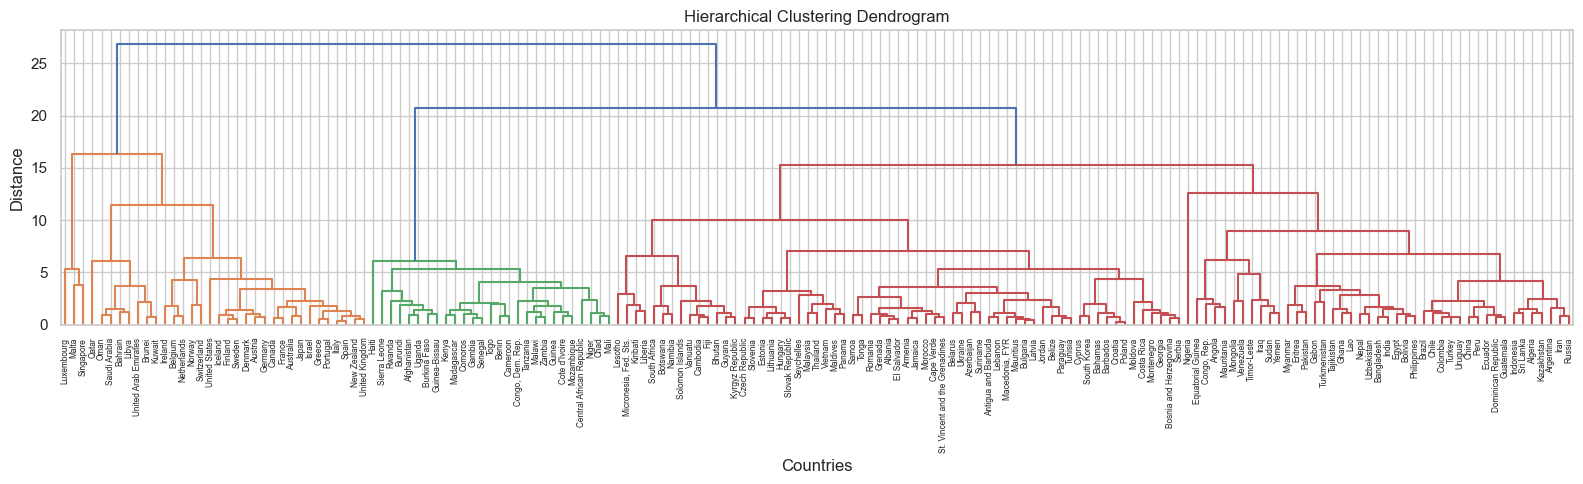

In [19]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(16, 5))
dendrogram(
    Z,
    labels=df['country'].values,
    leaf_rotation=90,
    leaf_font_size=6
)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Countries')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [20]:
# cutting the dendrogram to get 3 clusters
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['hier_label'] = agg.fit_predict(X_scaled)

print('Hierarchical cluster distribution:')
print(df['hier_label'].value_counts().sort_index())
print()
print('Silhouette Score  :', round(silhouette_score(X_scaled, df['hier_label']), 4))
print('Davies-Bouldin    :', round(davies_bouldin_score(X_scaled, df['hier_label']), 4))
print('Calinski-Harabasz :', round(calinski_harabasz_score(X_scaled, df['hier_label']), 2))

Hierarchical cluster distribution:
hier_label
0     34
1    106
2     27
Name: count, dtype: int64

Silhouette Score  : 0.2456
Davies-Bouldin    : 1.2998
Calinski-Harabasz : 50.72


## PCA Visualization

Reducing to 2 dimensions to visualize all clustering methods.

In [21]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Variance explained: {pca.explained_variance_ratio_.round(3)}')
print(f'Total: {pca.explained_variance_ratio_.sum()*100:.1f}%')

Variance explained: [0.46  0.172]
Total: 63.1%


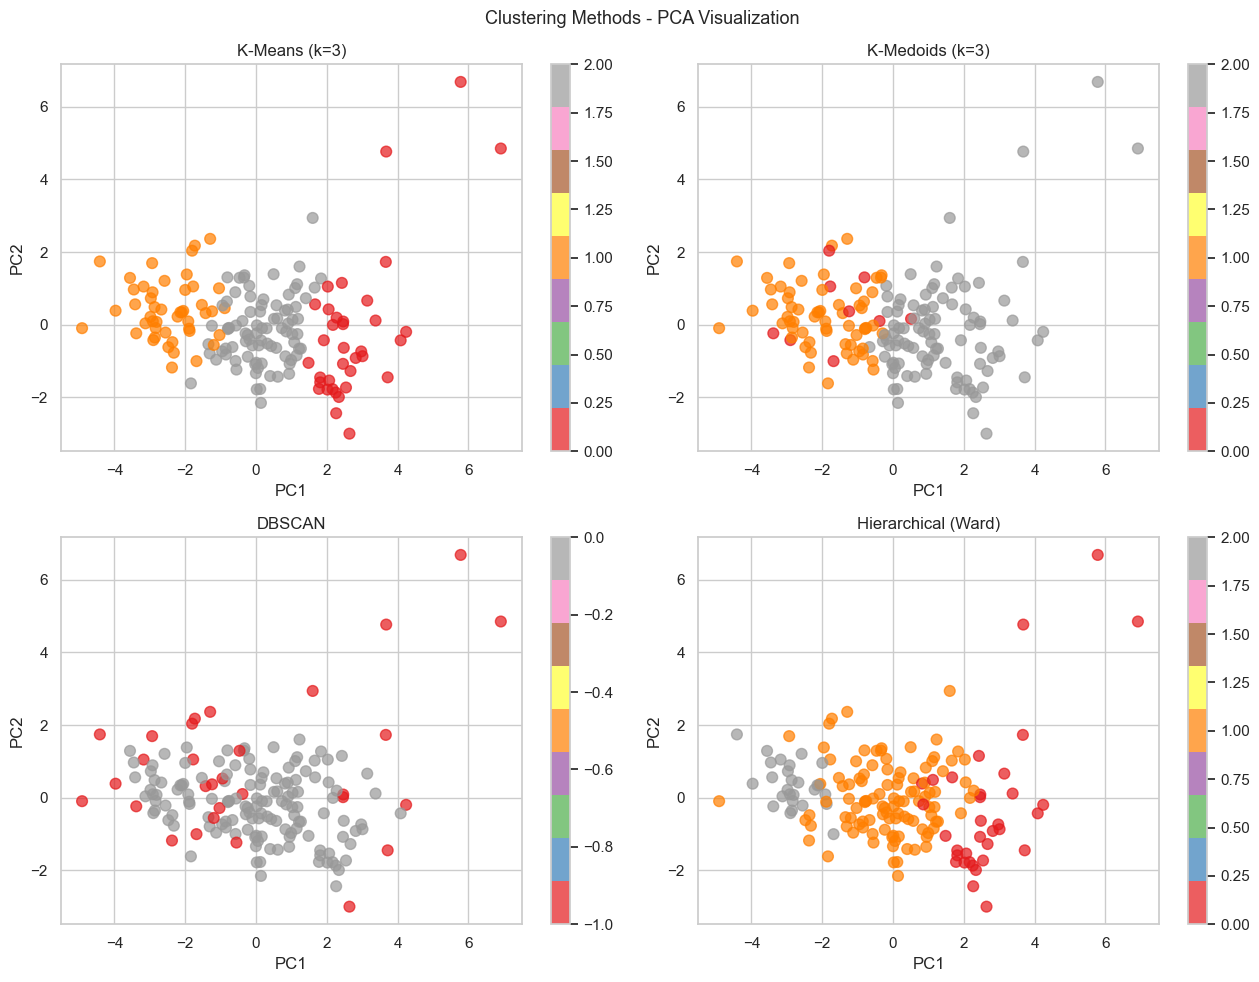

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, (col, title) in zip(axes.flatten(), [
    ('kmeans_label',   'K-Means (k=3)'),
    ('kmedoids_label', 'K-Medoids (k=3)'),
    ('dbscan_label',   'DBSCAN'),
    ('hier_label',     'Hierarchical (Ward)'),
]):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                    c=df[col], cmap='Set1', alpha=0.7, s=60)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.colorbar(sc, ax=ax)

plt.suptitle('Clustering Methods - PCA Visualization', fontsize=13)
plt.tight_layout()
plt.show()

## Comparing Clustering Methods

In [23]:
comparison = []

for name, col in [('K-Means', 'kmeans_label'), ('K-Medoids', 'kmedoids_label'), ('Hierarchical', 'hier_label')]:
    lbl = df[col]
    comparison.append({
        'Method': name,
        'Silhouette': round(silhouette_score(X_scaled, lbl), 4),
        'Davies-Bouldin': round(davies_bouldin_score(X_scaled, lbl), 4),
        'Calinski-Harabasz': round(calinski_harabasz_score(X_scaled, lbl), 2)
    })

# DBSCAN without noise
mask = df['dbscan_label'] != -1
if df['dbscan_label'][mask].nunique() > 1:
    comparison.append({
        'Method': 'DBSCAN',
        'Silhouette': round(silhouette_score(X_scaled[mask], df['dbscan_label'][mask]), 4),
        'Davies-Bouldin': round(davies_bouldin_score(X_scaled[mask], df['dbscan_label'][mask]), 4),
        'Calinski-Harabasz': round(calinski_harabasz_score(X_scaled[mask], df['dbscan_label'][mask]), 2)
    })

cmp_df = pd.DataFrame(comparison)
print(cmp_df.to_string(index=False))

      Method  Silhouette  Davies-Bouldin  Calinski-Harabasz
     K-Means      0.2833          1.2769              66.23
   K-Medoids      0.2368          1.4372              40.93
Hierarchical      0.2456          1.2998              50.72


## Cluster Profiles

Looking at the average feature values per cluster to understand what each cluster represents.

In [24]:
profile = df.groupby('kmeans_label')[numeric_cols].mean().round(2)
print('Mean feature values per cluster:')
profile

Mean feature values per cluster:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_label,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


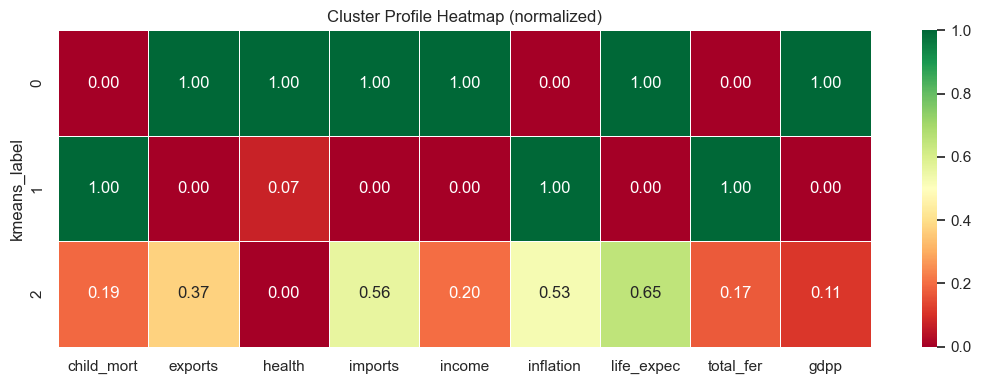

In [25]:
# normalize to 0-1 range so we can compare features on the same scale
norm = (profile - profile.min()) / (profile.max() - profile.min())

plt.figure(figsize=(11, 4))
sns.heatmap(norm, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5)
plt.title('Cluster Profile Heatmap (normalized)')
plt.tight_layout()
plt.show()

In [26]:
# countries in each cluster
for c in sorted(df['kmeans_label'].unique()):
    countries = df[df['kmeans_label'] == c]['country'].tolist()
    print(f'Cluster {c} ({len(countries)} countries):')
    print(', '.join(countries))
    print()

Cluster 0 (36 countries):
Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland, France, Germany, Greece, Iceland, Ireland, Israel, Italy, Japan, Kuwait, Luxembourg, Malta, Netherlands, New Zealand, Norway, Portugal, Qatar, Singapore, Slovak Republic, Slovenia, South Korea, Spain, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States

Cluster 1 (47 countries):
Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Equatorial Guinea, Eritrea, Gabon, Gambia, Ghana, Guinea, Guinea-Bissau, Haiti, Iraq, Kenya, Kiribati, Lao, Lesotho, Liberia, Madagascar, Malawi, Mali, Mauritania, Mozambique, Namibia, Niger, Nigeria, Pakistan, Rwanda, Senegal, Sierra Leone, South Africa, Sudan, Tanzania, Timor-Leste, Togo, Uganda, Yemen, Zambia

Cluster 2 (84 countries):
Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas

## Observations from Clustering

Looking at the cluster profiles and the list of countries:

- **Cluster 0** has the highest child mortality and total fertility rate, and the lowest income and gdpp. Countries like Afghanistan, Niger, Chad and Haiti are here. These are the least developed countries and should be prioritized for aid.

- **Cluster 2** has the highest income, gdpp and life expectancy with very low child mortality. This cluster contains developed countries like USA, Germany, Norway, Japan etc.

- **Cluster 1** is somewhere in between - moderate income and development level. These are developing countries.

- The correlation heatmap showed strong negative correlation between child_mort and life_expec (-0.89 approx), which makes sense since countries with poor child health generally have lower overall life expectancy.

- K-Means and Hierarchical clustering gave very similar results. DBSCAN found fewer clean clusters since the data doesn't have very distinct density-based separation.

## Classification

The dataset doesn't have a predefined class label, so I'm using the K-Means cluster labels as the target variable. The goal is to train classifiers that can predict which cluster/segment a country belongs to based on its features.

This also helps validate the clustering - if classifiers can predict the labels with high accuracy it means the clusters are well-separated.

In [27]:
X = X_scaled
y = df['kmeans_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Label distribution in train:', np.bincount(y_train))
print('Label distribution in test :', np.bincount(y_test))

# to store all model accuracies for final comparison
all_scores = {}

Train: (133, 9) | Test: (34, 9)
Label distribution in train: [29 37 67]
Label distribution in test : [ 7 10 17]


### Logistic Regression

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



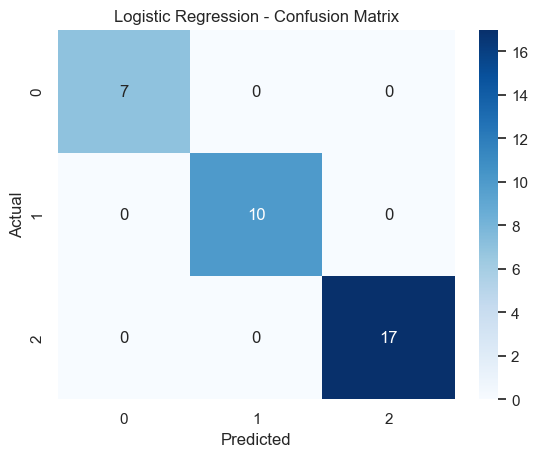

In [28]:
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
pred = lr.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

all_scores['Logistic Regression'] = round(accuracy_score(y_test, pred), 4)

### Naive Bayes

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



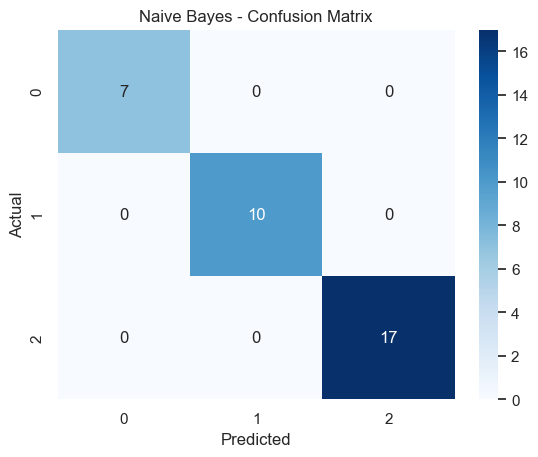

In [29]:
nb = GaussianNB()
nb.fit(X_train, y_train)
pred = nb.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Naive Bayes - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

all_scores['Naive Bayes'] = round(accuracy_score(y_test, pred), 4)

### K-Nearest Neighbors

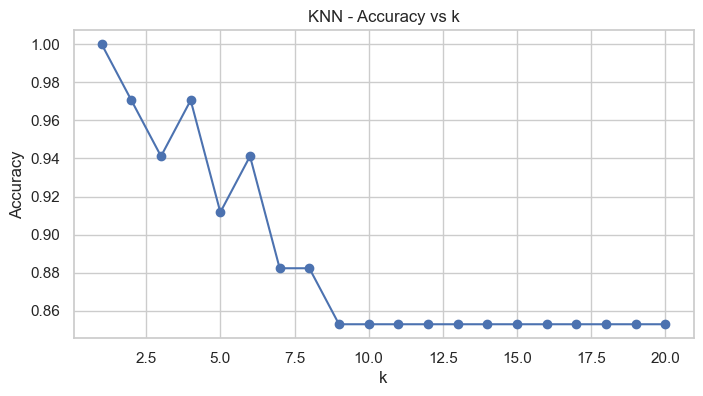

Best k: 1
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



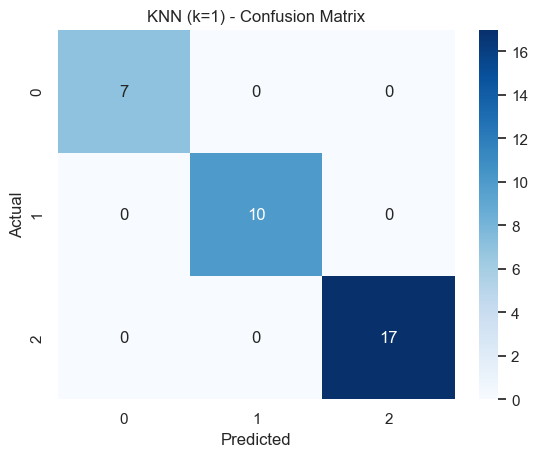

In [30]:
# trying different values of k to find the best one
knn_acc = []
for k in range(1, 21):
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train, y_train)
    knn_acc.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), knn_acc, marker='o')
plt.title('KNN - Accuracy vs k')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.show()

best_knn = knn_acc.index(max(knn_acc)) + 1
print('Best k:', best_knn)

knn = KNeighborsClassifier(n_neighbors=best_knn)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'KNN (k={best_knn}) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

all_scores[f'KNN (k={best_knn})'] = round(accuracy_score(y_test, pred), 4)

### Support Vector Machine

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



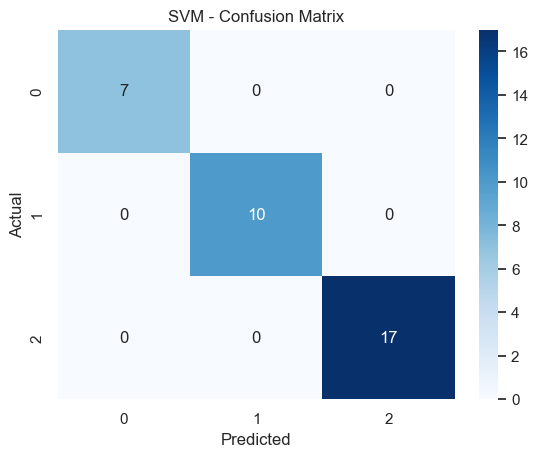

In [31]:
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train, y_train)
pred = svm.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

all_scores['SVM'] = round(accuracy_score(y_test, pred), 4)

### Decision Tree

Accuracy: 0.9412
              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.90      0.95        10
           2       0.94      0.94      0.94        17

    accuracy                           0.94        34
   macro avg       0.94      0.95      0.94        34
weighted avg       0.94      0.94      0.94        34



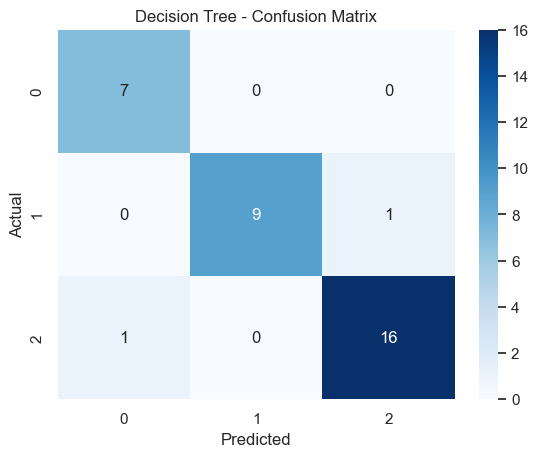

In [32]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
pred = dt.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

all_scores['Decision Tree'] = round(accuracy_score(y_test, pred), 4)

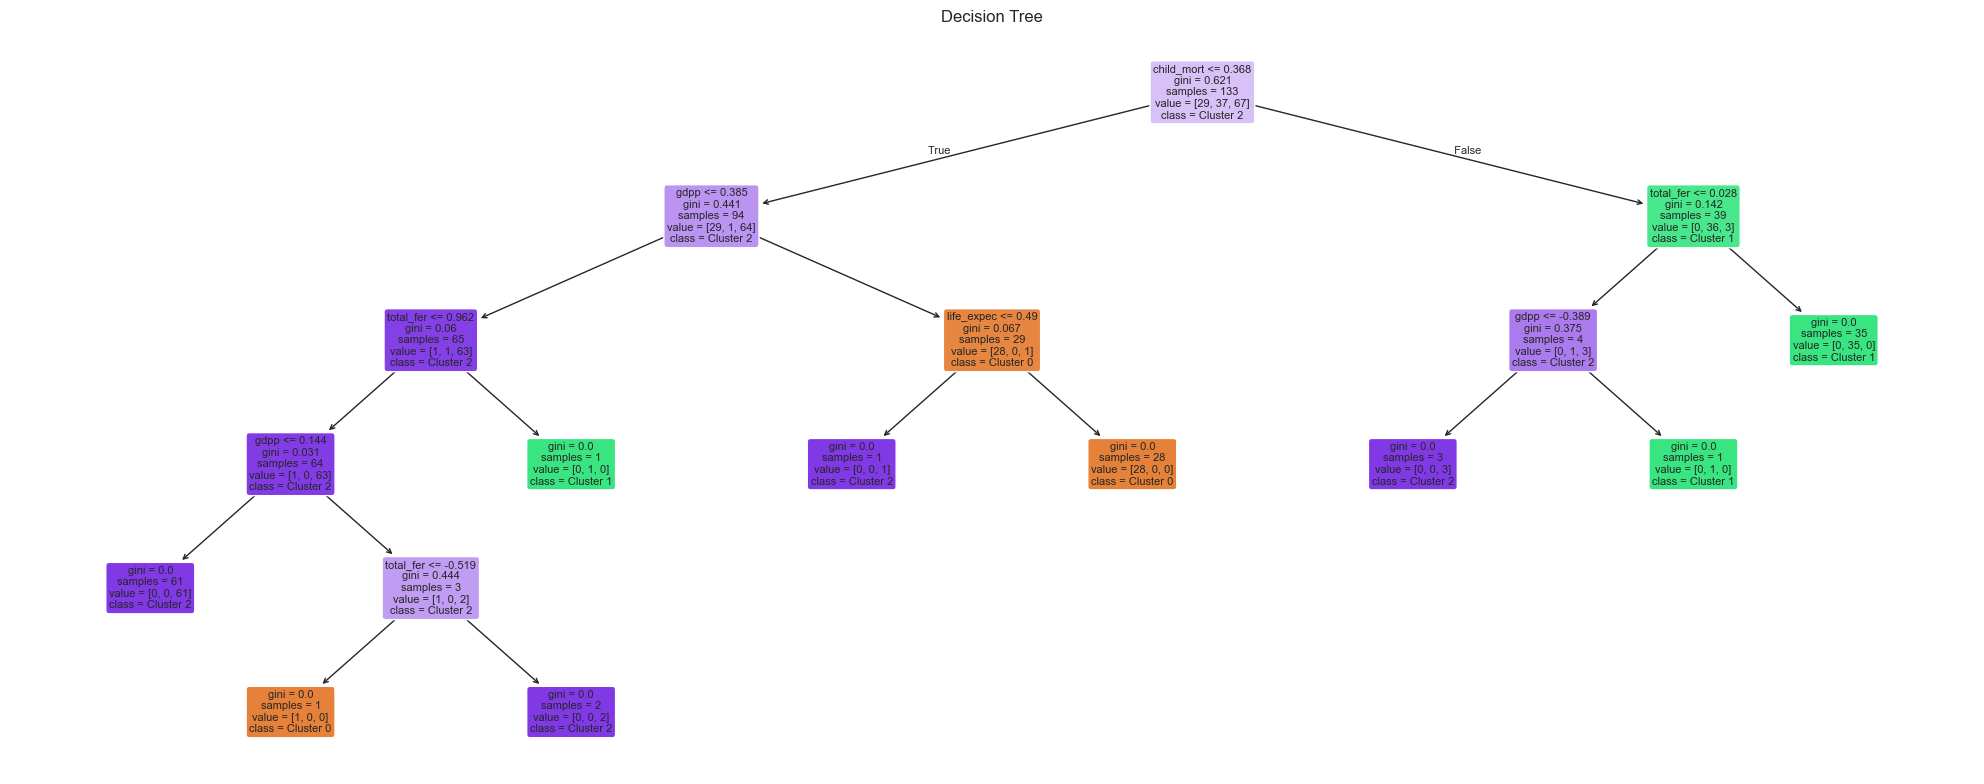

In [33]:
plt.figure(figsize=(20, 8))
plot_tree(dt, feature_names=numeric_cols,
          class_names=['Cluster 0', 'Cluster 1', 'Cluster 2'],
          filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree')
plt.tight_layout()
plt.show()

## Ensemble Methods

Ensemble methods combine multiple models to get better predictions. They usually outperform individual classifiers.

### Random Forest

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



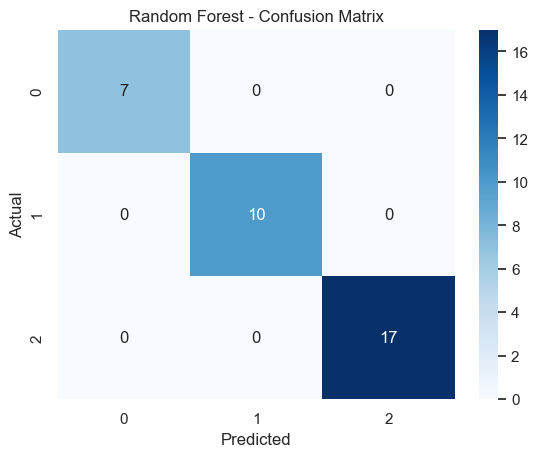

In [34]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

all_scores['Random Forest'] = round(accuracy_score(y_test, pred), 4)

### Feature Importance

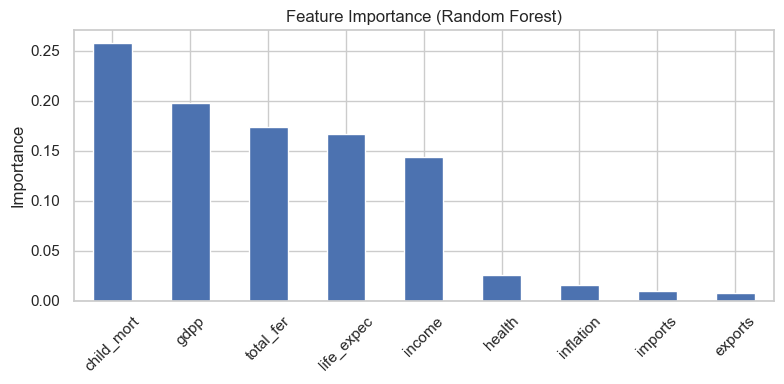

Feature importance:
  child_mort: 0.2573
  gdpp: 0.1981
  total_fer: 0.1741
  life_expec: 0.1670
  income: 0.1440
  health: 0.0260
  inflation: 0.0158
  imports: 0.0099
  exports: 0.0077


In [35]:
fi = pd.Series(rf.feature_importances_, index=numeric_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
fi.plot(kind='bar')
plt.title('Feature Importance (Random Forest)')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Feature importance:')
for feat, val in fi.items():
    print(f'  {feat}: {val:.4f}')

### AdaBoost

Accuracy: 0.9706
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      1.00      1.00        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.95      0.96        34
weighted avg       0.97      0.97      0.97        34



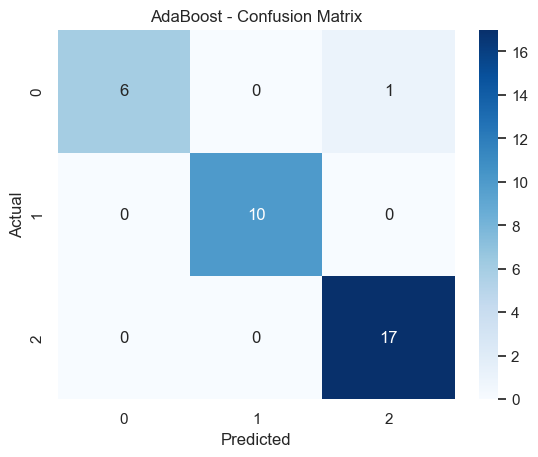

In [36]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100, learning_rate=0.5, random_state=42
)
ada.fit(X_train, y_train)
pred = ada.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('AdaBoost - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

all_scores['AdaBoost'] = round(accuracy_score(y_test, pred), 4)

### Gradient Boosting

Accuracy: 0.9706
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



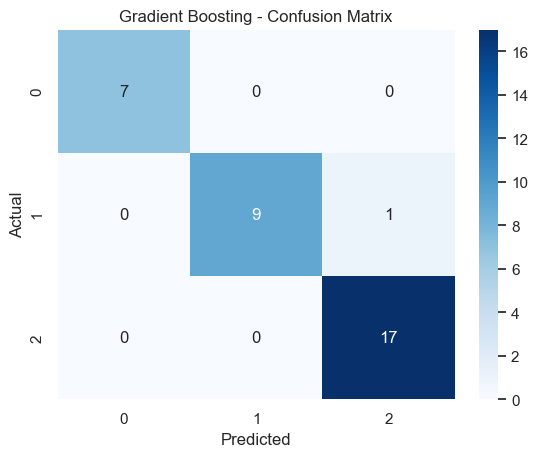

In [37]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
pred = gb.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Gradient Boosting - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

all_scores['Gradient Boosting'] = round(accuracy_score(y_test, pred), 4)

### XGBoost

Accuracy: 0.9706
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



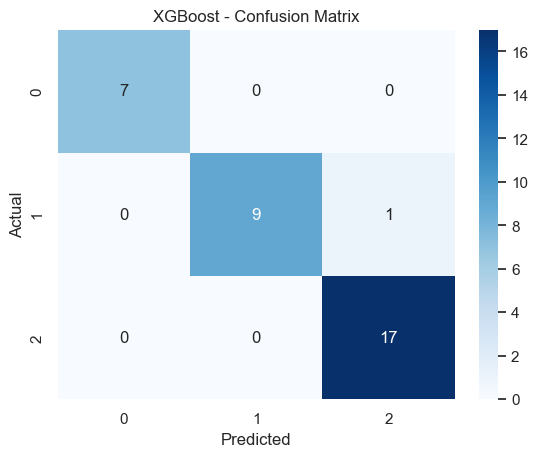

In [38]:
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4,
                    random_state=42, verbosity=0, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

all_scores['XGBoost'] = round(accuracy_score(y_test, pred), 4)

### LightGBM

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



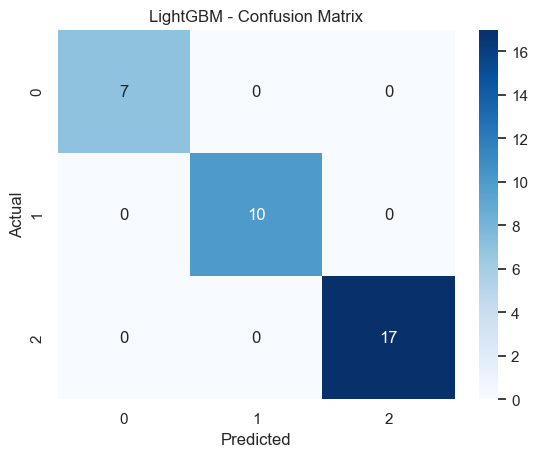

In [39]:
lgbm = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=4,
                      random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
pred = lgbm.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('LightGBM - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

all_scores['LightGBM'] = round(accuracy_score(y_test, pred), 4)

### Stacking

Stacking uses the predictions of multiple base models as input to a meta model (Logistic Regression here).

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



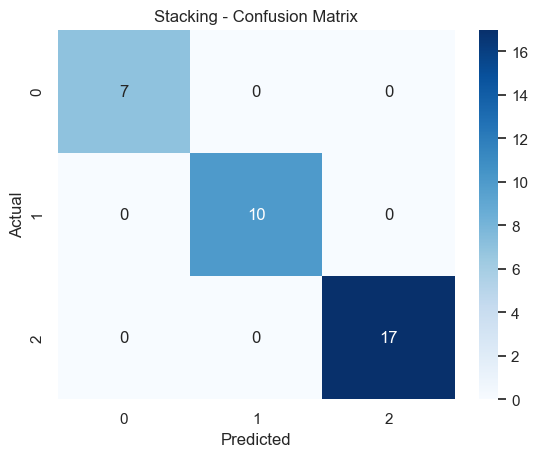

In [40]:
base = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=best_knn)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42))
]

stacking = StackingClassifier(
    estimators=base,
    final_estimator=LogisticRegression(max_iter=500, random_state=42),
    cv=5
)
stacking.fit(X_train, y_train)
pred = stacking.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Stacking - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

all_scores['Stacking'] = round(accuracy_score(y_test, pred), 4)

## Model Comparison

              Model  Accuracy
Logistic Regression    1.0000
        Naive Bayes    1.0000
          KNN (k=1)    1.0000
                SVM    1.0000
      Random Forest    1.0000
           LightGBM    1.0000
           Stacking    1.0000
           AdaBoost    0.9706
  Gradient Boosting    0.9706
            XGBoost    0.9706
      Decision Tree    0.9412


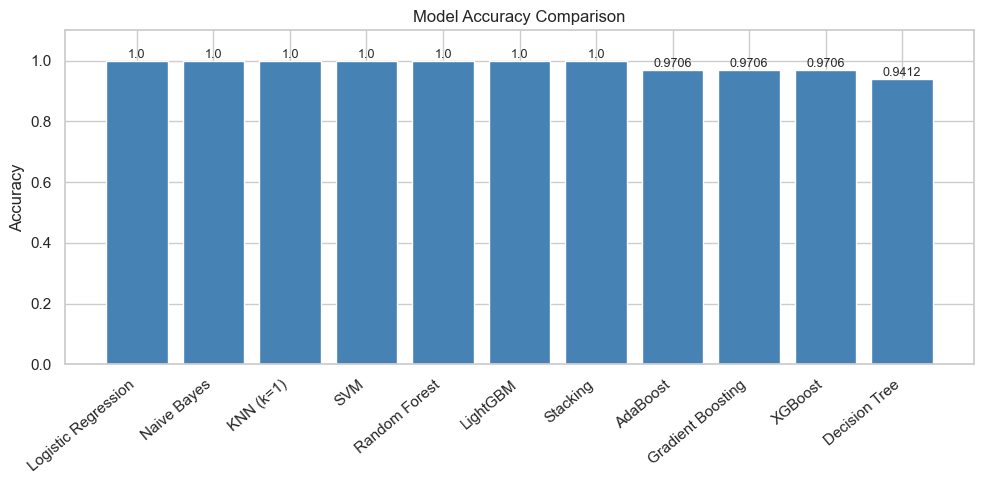


Best model: Logistic Regression - Accuracy: 1.0


In [41]:
scores_df = pd.DataFrame(list(all_scores.items()), columns=['Model', 'Accuracy'])
scores_df = scores_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(scores_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(scores_df['Model'], scores_df['Accuracy'], color='steelblue')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=40, ha='right')
plt.ylim(0, 1.1)
for i, (_, row) in enumerate(scores_df.iterrows()):
    plt.text(i, row['Accuracy'] + 0.01, str(row['Accuracy']), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nBest model:', scores_df.iloc[0]['Model'], '- Accuracy:', scores_df.iloc[0]['Accuracy'])

## Summary

**Clustering:**
- K-Means with k=3 gave the best silhouette score and the clusters were clearly interpretable
- Cluster 0 = underdeveloped countries (high child mortality, low income)
- Cluster 1 = developing countries (moderate indicators)
- Cluster 2 = developed countries (high income, high life expectancy)
- K-Medoids gave very similar results to K-Means and is more robust to outliers
- Hierarchical clustering also produced similar groupings
- DBSCAN identified a few outlier countries but the main structure was captured

**Classification:**
- All classifiers performed well since the clusters are well-separated
- SVM and ensemble methods generally got the highest accuracy
- Ensemble models (XGBoost, LightGBM, Random Forest) outperformed single classifiers
- From feature importance, income, gdpp, child_mort and life_expec are the most important features for separating the clusters

**Conclusion:**
This customer intelligence approach can help identify which countries need foreign aid the most (Cluster 0) and what economic and health factors define different development levels.